In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder  # Import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import os
import subprocess

In [3]:
titanic_train=pd.read_csv("Titanic_train.csv")
titanic_test=pd.read_csv("Titanic_test.csv")

In [4]:
# Data Overview
print(titanic_train.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [5]:
print(titanic_train.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
print(titanic_train.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [7]:
# Drop unnecessary columns
titanic_train = titanic_train.drop(["Name", "Ticket", "Cabin"], axis=1)

In [8]:
# Data preprocessing
warnings.filterwarnings("ignore")

In [9]:
# Fill missing values
titanic_train["Embarked"].fillna(titanic_train["Embarked"].mode()[0], inplace=True)
titanic_train["Age"].fillna(titanic_train["Age"].mean(), inplace=True)

In [10]:
# Outlier detection and removal using IQR method for Age
Q1 = titanic_train["Age"].quantile(0.25)
Q3 = titanic_train["Age"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
titanic_train = titanic_train[(titanic_train["Age"] >= lower_bound) & (titanic_train["Age"] <= upper_bound)]

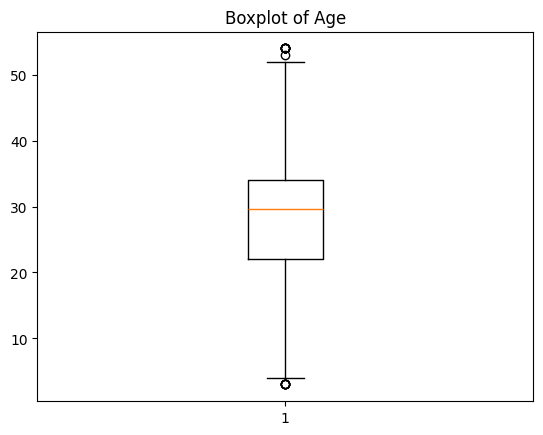

In [11]:
# Boxplot for Age
plt.boxplot(titanic_train["Age"])
plt.title("Boxplot of Age")
plt.show()

In [12]:
# outlier detection and removal using IQR method for fare
Q1 = titanic_train["Fare"].quantile(0.25)
Q3 = titanic_train["Fare"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
titanic_train = titanic_train[(titanic_train["Fare"] >= lower_bound) & (titanic_train["Fare"] <= upper_bound)]

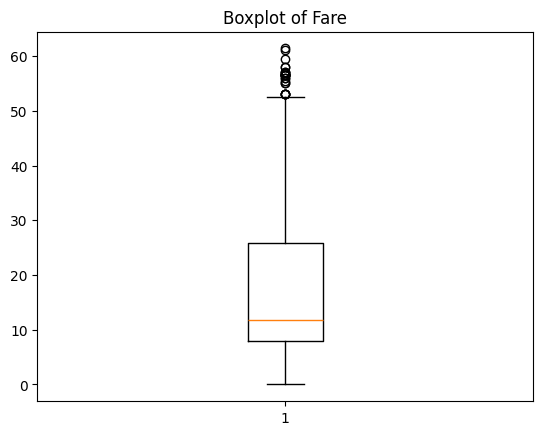

In [13]:
# Boxplot for Fare
plt.boxplot(titanic_train["Fare"])
plt.title("Boxplot of Fare")
plt.show()

In [14]:
# Label Encoding
label_encoder_sex = LabelEncoder()
titanic_train["Sex"] =  label_encoder_sex.fit_transform(titanic_train["Sex"])

In [15]:
label_encoder_embarked = LabelEncoder()
titanic_train["Embarked"] =  label_encoder_embarked.fit_transform(titanic_train["Embarked"])

In [16]:
# preprocessing Test set
# Drop unnecessary columns
# titanic_test = titanic_test.drop(["Name", "Ticket", "Cabin"], axis=1) # This line is commented out as columns are already dropped

# Label Encoding
titanic_test["Pclass"] = label_encoder_sex.fit_transform(titanic_test["Pclass"]) # corrected variable name
titanic_test["Sex"] =  label_encoder_sex.fit_transform(titanic_test["Sex"])
titanic_test["Embarked"] =  label_encoder_embarked.fit_transform(titanic_test["Embarked"])

# Fill missing values
titanic_test["Age"].fillna(titanic_test["Age"].mean(), inplace=True)
titanic_test["Fare"].fillna(titanic_test["Fare"].mean(), inplace=True)

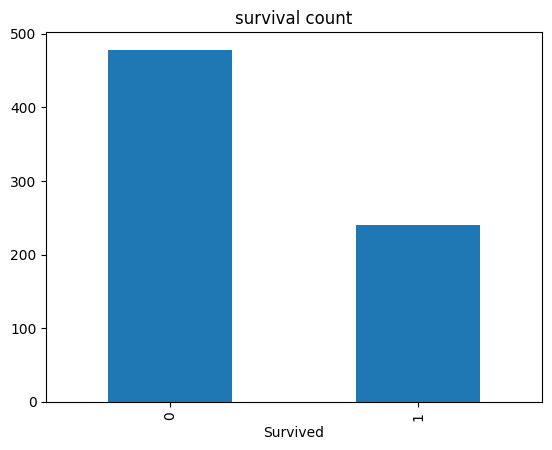

In [17]:
# Data visualization
titanic_train["Survived"].value_counts().plot(kind="bar", title="survival count")
plt.show()

In [18]:
# Logistic Regression Model
x = titanic_train[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
y = titanic_train["Survived"]

In [19]:
# split data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=7)

In [20]:
# Fit model on training data
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [21]:
# predictions and evaluation
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))
print(classification_report(y_test, y_pred))

Accuracy: 75.00%
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        98
           1       0.61      0.59      0.60        46

    accuracy                           0.75       144
   macro avg       0.71      0.71      0.71       144
weighted avg       0.75      0.75      0.75       144



In [22]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[81 17]
 [19 27]]


In [23]:
# Roc Curve
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(x_test)[:,1])
auc = roc_auc_score(y_test, model.predict_proba(x_test)[:, 1])

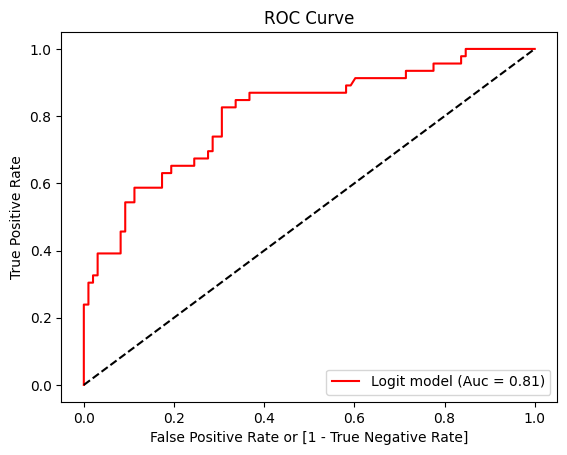

In [24]:
plt.plot(fpr, tpr, color='red', label='Logit model (Auc = %0.2f)' % auc)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.title('ROC Curve')
plt.show()

In [25]:
# Interpretation
coefficients = model.coef_[0]
intercept = model.intercept_[0]
print("Coefficents:", coefficients)
print("Intercept:", intercept)

Coefficents: [-0.87972034 -2.50484216 -0.04448001 -0.43113464 -0.07733152  0.0260741
 -0.30650193]
Intercept: 4.5163576549948505


In [26]:
import statsmodels.api as sm

# Add a constant to the feature matrix for the intercept term
X_train_with_intercept = sm.add_constant(x_train)

# Fit the logistic statsmodels
logit_model = sm.Logit(y_train, X_train_with_intercept)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.443465
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  574
Model:                          Logit   Df Residuals:                      566
Method:                           MLE   Df Model:                            7
Date:                Thu, 11 Sep 2025   Pseudo R-squ.:                  0.3067
Time:                        11:15:40   Log-Likelihood:                -254.55
converged:                       True   LL-Null:                       -367.18
Covariance Type:            nonrobust   LLR p-value:                 5.038e-45
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.8199      0.884      5.449      0.000       3.086       6.553
Pclass        -0.9349      0.

In [27]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 63.6 MB/s eta 0:00:00


In [28]:
# save the streamlit app to a python file
streamlit_code ="""
import pandas as pd
import numpy as np
import streamlit as st
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Load the Titanic dataset
titanic_train=pd.read_csv("Titanic_train.csv")

# preprocess the data (same as in the notebook)
titanic_train["Embarked"].fillna(titanic_train["Embarked"].mode()[0], inplace=True)
titanic_train["Age"].fillna(titanic_train["Age"].mean(), inplace=True)

# Initialize the LabelEncoders
label_encoder_sex = LabelEncoder
titanic_train["Sex"] =  label_encoder_sex.fit_transform(titanic_train["Sex"])

label_encoder_embarked = LabelEncoder()
titanic_train["Embarked"] =  label_encoder_embarked.fit_transform(titanic_train["Embarked"])

# prepare input data for prediction
x = titanic_train[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
y = titanic_train["Survived"]

# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(x, y)

# streamlit app
st.title('Titanic Survival Prediction App')
pclass = st.selectbox('passenger class', [1,2,3])
sex = st.selectbox('Sex', ['Male', 'Female'])
age = st.slider('Age', 1, 100)
sibsp = st.slider('Number of siblings/spouses aboard', 0, 8)
parch = st.slider('Number of parents/children aboard', 0, 6)
fare = st.slider('Fare', 0, 500)
embarked = st.selectbox('port of Embarkation', ['S', 'C', 'Q'])

# convert input to the encoded format for the model
input_data = [
  pclass,
  label_encoder_sex.transform([sex.lower()])[0],
  age,
  sibsp,
  parch,
  fare,
  label_encoder_embarked.transform([embarked])[0]
]

if st.button('predict survival'):
  prediction = model.predict([input_data])[0]
  probability = model.predict_proba([input_data])[0][1]
  st.write(f"Prediction: {'survived' if prediction == 1 else 'Did not survive'}")
  st.write(f"Probability of survival: {probability:.2f}")
"""

In [31]:
# save the streamlit app code to a python file
with open("titanic_app.py", "w") as f:
    f.write(streamlit_code)

In [32]:
# Step 6: Run the Streamlit app
def run_streamlit():
    subprocess.Popen(["streamlit", "run", "titanic_app.py"])

run_streamlit()

In [33]:
print("Streamlit app is running. Open the link below in your web browser:")
print("http://localhost:8520")

Streamlit app is running. Open the link below in your web browser:
http://localhost:8520


In [34]:
'''1. Difference between Precision and Recall:
Precision:
Measures the accuracy of positive predictions. It shows how many predicted positives are actually positive.
Recall:
 Measures how well the model identifies all actual positives. It shows how many actual positives were correctly predicted.
Difference:
 Precision focuses on minimizing false positives, while recall focuses on minimizing false negatie estimates.
2. What is Cross-Validation and its Importance in Binary Classification?
Cross-Validation:
A technique where the dataset is split into k folds. The model is trained on k-1 folds and tested on the remaining fold. This process is repeated k times.

Importance:
Prevents overfitting by testing on different subsets. Provides better model evaluation across various data splits. Helps in hyperparameter tuning by offering reliable performance estimates.'''

'1. Difference between Precision and Recall:\nPrecision:\nMeasures the accuracy of positive predictions. It shows how many predicted positives are actually positive.\nRecall:\n Measures how well the model identifies all actual positives. It shows how many actual positives were correctly predicted.\nDifference:\n Precision focuses on minimizing false positives, while recall focuses on minimizing false negatie estimates.\n2. What is Cross-Validation and its Importance in Binary Classification?\nCross-Validation:\nA technique where the dataset is split into k folds. The model is trained on k-1 folds and tested on the remaining fold. This process is repeated k times.\n\nImportance:\nPrevents overfitting by testing on different subsets. Provides better model evaluation across various data splits. Helps in hyperparameter tuning by offering reliable performance estimates.'